In [11]:
from langchain_qdrant import QdrantVectorStore, FastEmbedSparse
from qdrant_client import QdrantClient
from dotenv import load_dotenv
import os
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_community.tools import WikipediaQueryRun
from langchain_tavily import TavilySearch
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.tools import Tool

from dataclasses import dataclass
from pydantic import BaseModel, Field
from typing import List
from langchain_core.documents import Document

from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
import ast


In [12]:
class ProcessChainOfThought:

    def __init__(self):
        self.client = QdrantClient(
                            url=os.getenv('QDRANT_API_URL'),
                            api_key=os.getenv('QDRANT_API_KEY')
                        )
        self.dense_embedding = HuggingFaceEmbeddings(model = 'sentence-transformers/all-MiniLM-L12-v2')
        self.sparse_embedding = FastEmbedSparse(model_name ='Qdrant/bm25')
        
        self.qdrantdb = QdrantVectorStore(
            client=self.client,
            collection_name= os.getenv('COLLECTIONNAME'),
            embedding=self.dense_embedding,
            sparse_embedding=self.sparse_embedding
        )
        self.wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results= 5, doc_content_chars_max= 2000))
        self.tavily_tool = TavilySearch(
            max_results=5,
            topic="general",
        )

    @property
    def getPBIRetriver(self):

        return self.qdrantdb.as_retriever(
            search_type = 'mmr',
                search_kwarg = {
                    "k":10
                }
        )
    
    


In [13]:
# @dataclass
class QueryPlannerAndDecom(BaseModel):

    question: str
    subQuestion : List[str] = []
    retrivedDocs : List[Document] = []
    answer: str

In [14]:
class DecomposedQueries(BaseModel):
    """List of simple, distinct, and independent sub-questions."""
    refined_queries: List[str] = Field(description="A list of fully independent sub-questions necessary to answer the original complex query."
    )

In [15]:
llm = ChatGroq(model='openai/gpt-oss-120b')
pbi_obj = ProcessChainOfThought()
pbi_retriver = pbi_obj.getPBIRetriver

In [16]:
def queryPlanner(state: QueryPlannerAndDecom) -> QueryPlannerAndDecom:

    """ 
    Analyzes a complex user query and generates an optimal list of sub-queries
    or a single optimized query for the RAG system's retrieval step.

    The Query Planner utilizes an LLM to perform **meta-reasoning** on the initial
    request, breaking down multi-part questions (e.g., "What were the sales for Q4 
    and how did they compare to the marketing budget?") into distinct, retrieval-friendly
    components. This is a critical step in advanced RAG pipelines.

    :param state : object of QueryPlannerAndDecom include below members.
                    a. question (String)
                    b. subQuestion (List of String)
                    c. retrivedDocs (List of Document)
                    d. answer (string)
    :type : QueryPlannerAndDecom

    :returns : object of QueryPlannerAndDecom with Modified Value of attributes subQuestion.

    :Raises :
        APIError: If the LLM API call fails or returns an error.
        ValueError: If the model_config is invalid or missing required keys.
    """
    prompt = f""" 
                You are an expert Query Decomposer agent for a Retrieval-Augmented Generation (RAG) system. Your sole function is to analyze a complex, multi-part user question and break it down into a list of simple, distinct, and independent sub-questions that are necessary to fully answer the original query.

                * **Goal:** Create focused, maximum-retrieval sub-queries.
                * **Rule 1 (Independence):** Each sub-question must be answerable on its own.
                * **Rule 2 (Clarity):** Explicitly re-state all subjects and entities in every sub-question. Do not use pronouns.
                * **Rule 3 (Formatting):** Output **ONLY** the list of strings using the provided JSON schema.
                
                **Question**: {state.question}   

                **subQuestion**

                Example:
                "What is Power BI"
                ["1. Define Power BI?", "2. Define Power BI Components?","3. Define Power BI Usage?"]

                Please add Questions only in subQuestion List not other details. for more details refer function docstring.  

                **Final Answer:**     
            """
    structured_llm = llm.with_structured_output(DecomposedQueries)
    result = structured_llm.invoke(prompt)
    # print(result.content)
    subqus = [qus.strip() for qus in result.refined_queries]
    return state.model_copy(update={
        "subQuestion" :  subqus
    })
    
    

In [17]:
def documentRetrival(state: QueryPlannerAndDecom) -> QueryPlannerAndDecom:

    """ 
    Extracts relevant documents based on the sub-questions of a Planning and Decomposition query.

        This node leverages a Language Model (LLM) to intelligently analyze a set of
        "Planning and Decomposition" sub-questions (e.g., 'What is Span of Control?') and retrieve
        the most pertinent documents from a knowledge base that contain the answers or
        required context for generating a final answer.

        :param state: Object of QueryPlannerAndDecom having below 4 attributes
                    a. question (String)
                    b. subQuestion (List of String)
                    c. retrivedDocs (List of Document)
                    d. answer (string)
        :type: QueryPlannerAndDecom
                    
        :returns: object of QueryPlannerAndDecom with updated retrivedDocs attributes.
                A consolidated list of unique, highly relevant documents extracted
                from the `knowledge_base`. Documents are typically scored or selected
                based on their relevance to the combined sub-questions.
    """

    docs = []

    for qus in state.subQuestion:

        doclist = pbi_retriver.invoke(qus)
        docs.extend(doclist)

    return state.model_copy(
        update={
            "retrivedDocs" : docs
        }
    )


In [18]:
def generateAnswer(state: QueryPlannerAndDecom) -> QueryPlannerAndDecom:

    """ 
    Synthesizes the final answer by consolidating retrieved documents.

    This terminal node in the LLM chain takes the list of relevant documents, 
    feeds them into the Language Model (LLM) as context, and prompts the LLM to generate a single, coherent, and
    comprehensive answer that addresses all parts of the original query.

    :param state: Object of QueryPlannerAndDecom having below 4 attributes
                    a. question (String)
                    b. subQuestion (List of String)
                    c. retrivedDocs (List of Document)
                    d. answer (string)
    :type: QueryPlannerAndDecom
                    
    :returns: object of QueryPlannerAndDecom with updated answer based on retrivedDocs attributes.
                The final, comprehensive answer string generated by the LLM, grounded
                in the provided documents and addressing the user's original query.
    """

    context_documents = '\n\n'.join([doc.page_content for doc in state.retrivedDocs])
    prompt = f""" 
                You are an expert Q&A system. Your task is to generate a single, comprehensive, and well-structured answer to the user's original query.

                    **Instructions:**
                    1.  Read the **Original Query** and the intermediate **Sub-Questions**.
                    2.  Carefully analyze the content of the **Context Documents** provided below.
                    3.  Synthesize the information from the documents to construct a complete answer that addresses all parts of the Original Query.
                    4.  Do not introduce any information that is not explicitly present in the Context Documents.
                    5.  Structure your final answer clearly using markdown headings and bullet points where appropriate.

                    **Original Query:**
                    {state.question}

                    **Sub-Questions (for context on intent):**
                    {state.subQuestion}

                    **Context Documents:**
                    {context_documents}

                    **Final Answer:**
            """
    
    result = llm.invoke(prompt).content
    
    return state.model_copy(update={"answer": result})
    
    
    

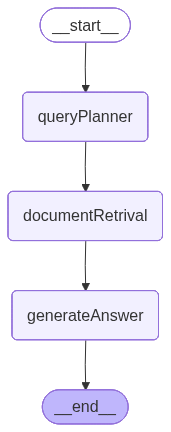

In [19]:
graph = StateGraph(QueryPlannerAndDecom)

graph.add_node("queryPlanner", queryPlanner)
graph.add_node("documentRetrival",documentRetrival)
graph.add_node("generateAnswer", generateAnswer)

graph.add_edge(START, "queryPlanner")
graph.add_edge("queryPlanner","documentRetrival")
graph.add_edge("documentRetrival", "generateAnswer")
graph.add_edge("generateAnswer", END)

graph_builder = graph.compile()
graph_builder

In [23]:
obj = QueryPlannerAndDecom(
    question = "What is Power BI",
    subQuestion  = [],
    retrivedDocs  = [],
    answer = ""
)
result = graph_builder.invoke(obj)
print(result['question'])
print(result['subQuestion'])
print(result['answer'])

What is Power BI
['1. Define Power BI?', '2. Define Power BI Components?', '3. Define Power BI Usage?']
## 1. What is Power BI?  

Power BI is **a collection of software services, apps, and connectors** that work together to turn unrelated data sources into **coherent, visually immersive, and interactive insights**.  

- **Purpose** – Enable users to create reports and dashboards that deliver business analytics and insights, helping organisations make data‑driven decisions.  
- **Key capabilities** –  
  - Connect to hundreds of data sources.  
  - Perform powerful data modeling (relationships, calculations).  
  - Execute extensive data transformation (cleaning and shaping).  
  - Build rich visualisations and share actionable insights across the organisation.

---

## 2. Main Components of Power BI  

| Component | Role | Typical Use |
|-----------|------|-------------|
| **Power BI Desktop** (The Creator) | Free desktop application for development and authoring. | Connect to data, t